# Decision Trees Introduction

This notebook introduces decision trees, a fundamental supervised machine learning algorithm used for both classification and regression tasks. Decision trees work by creating a model that predicts the value of a target variable by learning simple decision rules inferred from the data features.

## 1. Import Required Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For decision trees and evaluation
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For visualization (prettier trees)
import graphviz
from sklearn.tree import export_graphviz

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Understanding Decision Trees

Decision trees are a supervised learning algorithm used for classification and regression. They work by splitting the data based on feature values to create a tree-like model of decisions.

### Key Components:
- **Root Node**: The topmost node representing the entire dataset
- **Decision Nodes**: Nodes where the data is split based on feature values
- **Leaf/Terminal Nodes**: Nodes that provide the final classification/prediction
- **Branches/Edges**: Connections between nodes showing decision paths

### Splitting Criteria:
Decision trees use metrics like **Gini Impurity** or **Entropy** to determine how to split data at each node.

In [2]:
# Let's demonstrate how splitting criteria work with a simple example

def calculate_gini(classes):
    """Calculate Gini impurity for a set of classes"""
    # Convert to numpy array if it's a list
    if isinstance(classes, list):
        classes = np.array(classes)
    
    # Get unique classes and their counts
    unique_classes, counts = np.unique(classes, return_counts=True)
    probabilities = counts / len(classes)
    
    # Calculate Gini impurity: 1 - sum(p_i^2)
    gini = 1 - np.sum(probabilities**2)
    return gini

def calculate_entropy(classes):
    """Calculate entropy for a set of classes"""
    # Convert to numpy array if it's a list
    if isinstance(classes, list):
        classes = np.array(classes)
    
    # Get unique classes and their counts
    unique_classes, counts = np.unique(classes, return_counts=True)
    probabilities = counts / len(classes)
    
    # Calculate entropy: -sum(p_i * log2(p_i))
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
    return entropy

# Create some example data
perfect_split = ['A', 'A', 'A', 'B', 'B', 'B']
imperfect_split = ['A', 'A', 'A', 'A', 'B', 'B']
worst_split = ['A', 'B', 'A', 'B', 'A', 'B']

print(f"Perfect Split (50/50):")
print(f"  - Gini Impurity: {calculate_gini(perfect_split):.4f}")
print(f"  - Entropy: {calculate_entropy(perfect_split):.4f}")

print(f"\nImperfect Split (67/33):")
print(f"  - Gini Impurity: {calculate_gini(imperfect_split):.4f}")
print(f"  - Entropy: {calculate_entropy(imperfect_split):.4f}")

print(f"\nWorst Split (50/50 mixed):")
print(f"  - Gini Impurity: {calculate_gini(worst_split):.4f}")
print(f"  - Entropy: {calculate_entropy(worst_split):.4f}")

Perfect Split (50/50):
  - Gini Impurity: 0.5000
  - Entropy: 1.0000

Imperfect Split (67/33):
  - Gini Impurity: 0.4444
  - Entropy: 0.9183

Worst Split (50/50 mixed):
  - Gini Impurity: 0.5000
  - Entropy: 1.0000


### Decision Making Process

Decision trees make predictions by following a path from the root node to a leaf node:
1. Start at the root node
2. For each decision node, evaluate the feature condition
3. Follow the branch that corresponds to the feature value
4. Continue until reaching a leaf node
5. Return the prediction (majority class/average value) at the leaf node

The beauty of decision trees lies in their interpretability - the decision process can be easily visualized and understood.

## 3. Dataset Preparation

Let's use the Iris dataset - a classic dataset for classification problems. It contains measurements of iris flowers from three different species.

In [3]:
# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for easier data exploration
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['target'] = y
iris_df['species'] = iris_df['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Display the first few rows
print("Iris Dataset Preview:")
iris_df.head()

Iris Dataset Preview:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# Basic statistics
print("Dataset shape:", iris_df.shape)
print("\nBasic statistics:")
iris_df.describe()

Dataset shape: (150, 6)

Basic statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


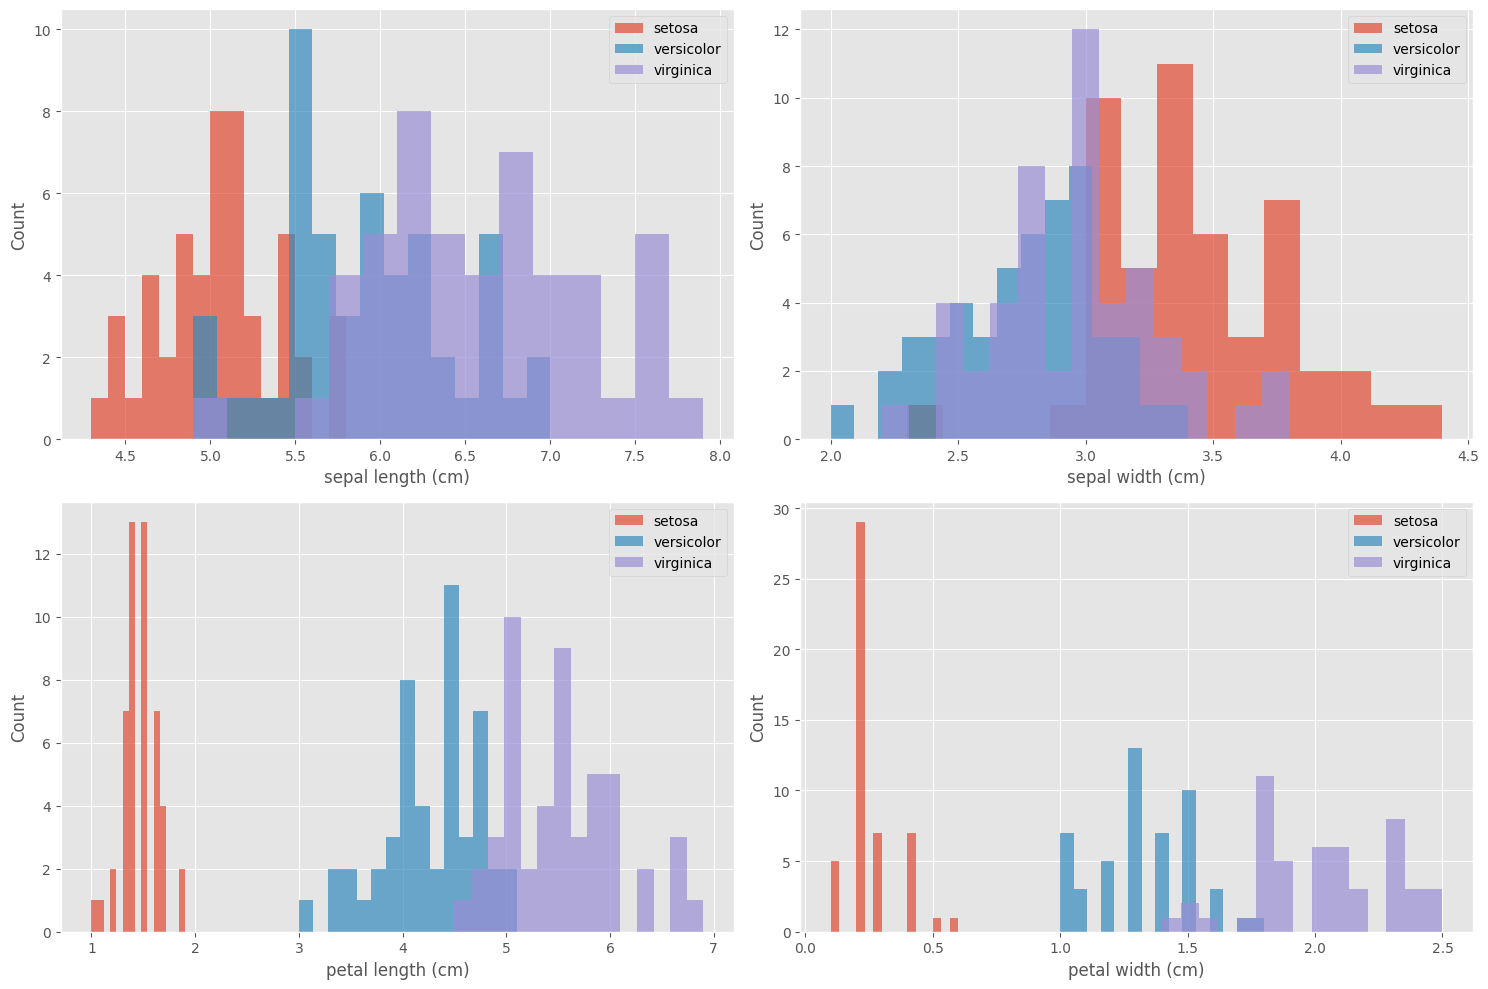

In [5]:
# Visualize the distribution of each feature by species
plt.figure(figsize=(15, 10))

for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    for species in [0, 1, 2]:
        plt.hist(iris_df[iris_df['target'] == species][feature], 
                 alpha=0.7, 
                 label=iris.target_names[species],
                 bins=15)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()

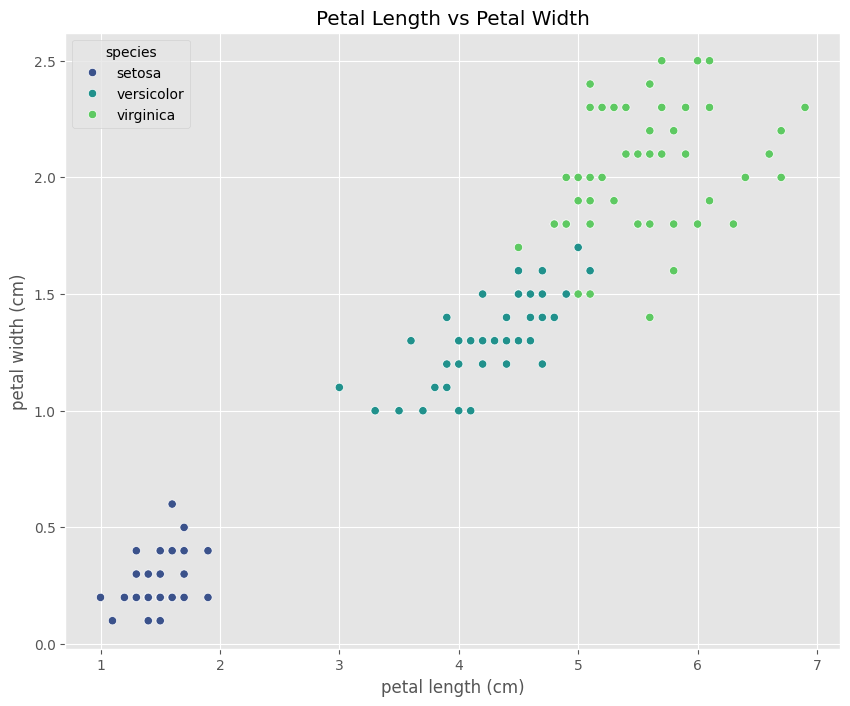

In [6]:
# Let's visualize the relationship between petal length and petal width with a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='petal length (cm)', 
    y='petal width (cm)', 
    hue='species',
    palette='viridis',
    data=iris_df
)
plt.title('Petal Length vs Petal Width')
plt.show()

# This visualization shows clear clustering, suggesting these features will be 
# useful for our decision tree to make accurate classifications

In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 105 samples
Testing set: 45 samples


## 4. Building a Simple Decision Tree

Now let's create a basic decision tree classifier using scikit-learn. We'll start with default parameters to understand how it works.

In [8]:
# Create a decision tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model
dt_classifier.fit(X_train, y_train)

print("Decision Tree Classifier created and trained!")

# Display some basic information about the trained tree
print(f"Tree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")
print(f"Feature importances: {dt_classifier.feature_importances_}")

# Display feature importances with feature names
feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance

Decision Tree Classifier created and trained!
Tree depth: 6
Number of leaves: 10
Feature importances: [0.         0.01911002 0.89326355 0.08762643]


,Feature,Importance
2,petal length (cm),0.893264
3,petal width (cm),0.087626
1,sepal width (cm),0.019110
0,sepal length (cm),0.000000


In [9]:
# Let's see the tree structure using text representation
print("Tree Structure:")
tree_text = export_text(dt_classifier, feature_names=iris.feature_names)
print(tree_text)

Tree Structure:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.60
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.60
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |--- class: 1
|   |  

## 5. Visualizing the Decision Tree

Let's visualize our decision tree to better understand how it makes decisions. This will help us interpret the model's logic.

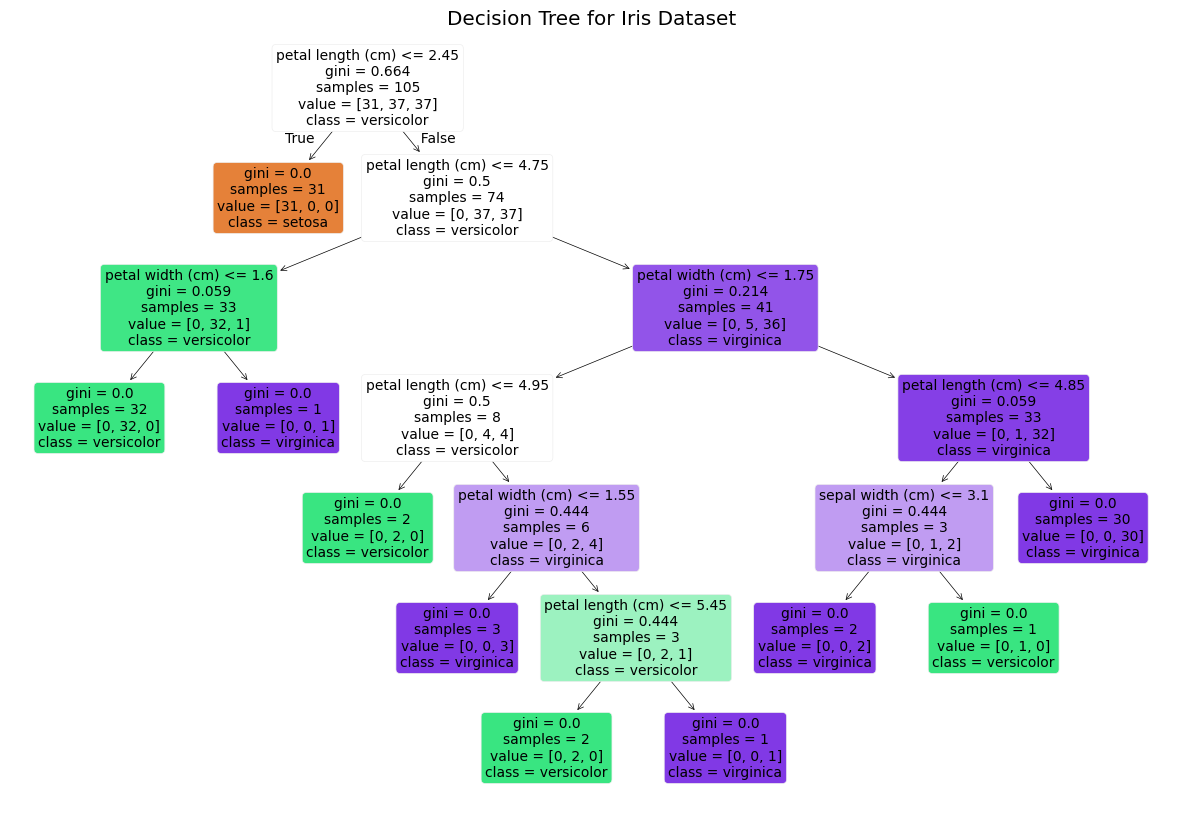

In [10]:
# Visualize the tree using matplotlib
plt.figure(figsize=(15, 10))
plot_tree(
    dt_classifier, 
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Iris Dataset")
plt.show()

In [11]:
# # For a nicer visualization, let's use graphviz
# # Note: This requires graphviz to be installed on your system

# # Create dot data
# dot_data = export_graphviz(
#     dt_classifier,
#     out_file=None,
#     feature_names=iris.feature_names,
#     class_names=iris.target_names,
#     filled=True,
#     rounded=True
# )

# # Create graph
# try:
#     graph = graphviz.Source(dot_data)
#     # Uncomment to save the graph as PDF
#     # graph.render("iris_decision_tree", format="pdf")
#     display(graph)
# except Exception as e:
#     print("Could not generate graphviz visualization. Error:", str(e))
#     print("If graphviz is not installed, you can use the matplotlib visualization above.")

```
ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH
```

1. Install Graphviz system package
   - https://graphviz.org/download/
   - C:\Program Files\Graphviz
2. Add Graphviz to System PATH
   - C:\Program Files\Graphviz\bin

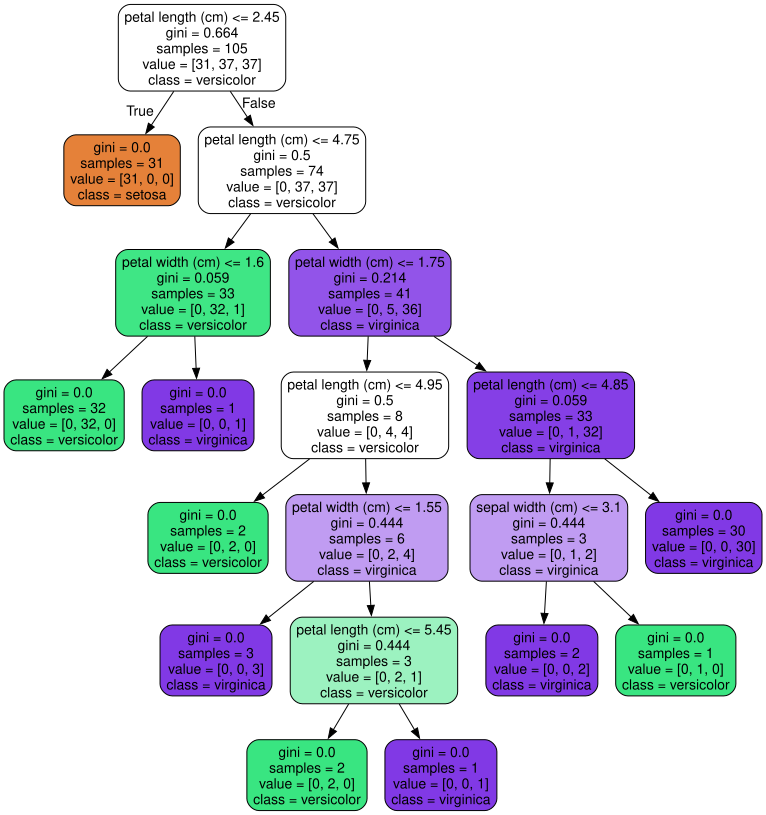

In [12]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

# Create dot data
dot_data = export_graphviz(
    dt_classifier,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

# Try creating and displaying graphviz output
try:
    graph = graphviz.Source(dot_data)
    display(graph)
except Exception as e:
    print("Could not generate Graphviz visualization. Error:", e)
    print("Make sure Graphviz is installed and 'dot' is in your PATH.")

### Understanding the Visualization

In the tree visualization:
- **Nodes** show the splitting feature and threshold
- **Colors** represent the majority class at each node
- **Gini** values show the impurity at that node
- **samples** shows how many samples reached that node
- **value** shows the distribution of classes in the node [setosa, versicolor, virginica]

Decision nodes ask a question about a feature, and depending on the answer, you follow a specific branch. Once you reach a leaf node, you have your classification.

## 6. Making Predictions

Let's use our trained decision tree to make predictions on the test set and see how it performs.

In [13]:
# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)
print("Predictions made:", len(y_pred))

# Show first few predictions vs actual values
comparison_df = pd.DataFrame({
    'Actual': [iris.target_names[i] for i in y_test[:10]],
    'Predicted': [iris.target_names[i] for i in y_pred[:10]]
})
comparison_df

Predictions made: 45


,Actual,Predicted
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


In [18]:
# # Let's trace through the decision path for a specific example
# def trace_decision_path(tree, features, feature_names):
#     """Trace the decision path for a specific sample"""
#     node_indicator = tree.decision_path([features])
#     leaf_node = tree.apply([features])[0]
    
#     # Get all nodes that this sample goes through
#     node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    
#     print(f"Decision path for sample: {features}")
#     print("-" * 50)
    
#     # Format the decision path
#     for i, node_id in enumerate(node_index):
#         # If not the leaf node
#         if node_id != leaf_node:
#             # Identify if the sample goes to the left or right child
#             if features[tree.feature[node_id]] <= tree.threshold[node_id]:
#                 threshold_sign = "<="
#                 direction = "left"
#             else:
#                 threshold_sign = ">"
#                 direction = "right"
                
#             print(f"Decision {i+1}: Is {feature_names[tree.feature[node_id]]} {threshold_sign} {tree.threshold[node_id]:.2f}? Yes, go {direction}.")
#         else:
#             # This is the leaf node
#             class_probabilities = tree.tree_.value[node_id][0] / sum(tree.tree_.value[node_id][0])
#             predicted_class = np.argmax(class_probabilities)
#             print(f"\nReached leaf node {node_id}!")
#             print(f"Class probabilities: {[f'{p:.2f}' for p in class_probabilities]}")
#             print(f"Predicted class: {iris.target_names[predicted_class]}")

# # Choose a sample from the test set
# sample_idx = 5  # You can change this to any index in the test set
# trace_decision_path(dt_classifier, X_test[sample_idx], iris.feature_names)

```
AttributeError: 'DecisionTreeClassifier' object has no attribute 'feature'
```

In [19]:
# Let's trace through the decision path for a specific example
def trace_decision_path(tree, features, feature_names, target_names):
    """Trace the decision path for a specific sample"""
    # Make sure features is 2D
    features_2d = np.array([features])
    
    node_indicator = tree.decision_path(features_2d)
    leaf_node = tree.apply(features_2d)[0]
    
    feature = tree.tree_.feature
    threshold = tree.tree_.threshold
    
    # Get all nodes that this sample goes through
    node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    
    print(f"Decision path for sample: {features}")
    print("-" * 50)
    
    for i, node_id in enumerate(node_index):
        if node_id != leaf_node:
            feat_index = feature[node_id]
            if features[feat_index] <= threshold[node_id]:
                threshold_sign = "<="
                direction = "left"
            else:
                threshold_sign = ">"
                direction = "right"
                
            print(f"Decision {i+1}: Is {feature_names[feat_index]} {threshold_sign} {threshold[node_id]:.2f}? Yes, go {direction}.")
        else:
            class_probabilities = tree.tree_.value[node_id][0]
            class_probabilities /= class_probabilities.sum()
            predicted_class = np.argmax(class_probabilities)
            print(f"\nReached leaf node {node_id}!")
            print(f"Class probabilities: {[f'{p:.2f}' for p in class_probabilities]}")
            print(f"Predicted class: {target_names[predicted_class]}")

# Example usage:
sample_idx = 5
trace_decision_path(dt_classifier, X_test[sample_idx], iris.feature_names, iris.target_names)

Decision path for sample: [5.4 3.4 1.5 0.4]
--------------------------------------------------
Decision 1: Is petal length (cm) <= 2.45? Yes, go left.

Reached leaf node 1!
Class probabilities: ['1.00', '0.00', '0.00']
Predicted class: setosa


## 7. Evaluating the Decision Tree Model

Now let's evaluate our model's performance using various metrics.

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



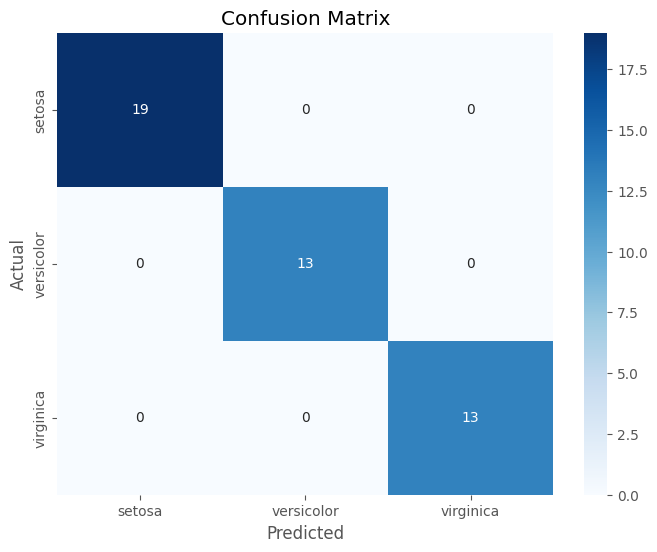

In [20]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Get detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Understanding the Evaluation Metrics

1. **Accuracy**: The proportion of correct predictions out of the total predictions.
2. **Precision**: The proportion of true positive predictions out of all positive predictions.
3. **Recall**: The proportion of true positive predictions out of all actual positives.
4. **F1-score**: The harmonic mean of precision and recall.
5. **Confusion Matrix**: Shows correct and incorrect classifications for each class.

## 8. Hyperparameter Tuning

Decision trees have several hyperparameters that can significantly affect their performance. Let's experiment with some key parameters to understand their impact:

- **max_depth**: Maximum depth of the tree
- **min_samples_split**: Minimum number of samples required to split a node
- **min_samples_leaf**: Minimum number of samples required to be at a leaf node
- **criterion**: Function to measure the quality of a split ("gini" or "entropy")

Max depth: 1, Train accuracy: 0.6476, Test accuracy: 0.7111
Max depth: 2, Train accuracy: 0.9429, Test accuracy: 0.9778
Max depth: 3, Train accuracy: 0.9524, Test accuracy: 1.0000
Max depth: 4, Train accuracy: 0.9714, Test accuracy: 1.0000
Max depth: 5, Train accuracy: 0.9905, Test accuracy: 1.0000
Max depth: 10, Train accuracy: 1.0000, Test accuracy: 1.0000
Max depth: None, Train accuracy: 1.0000, Test accuracy: 1.0000


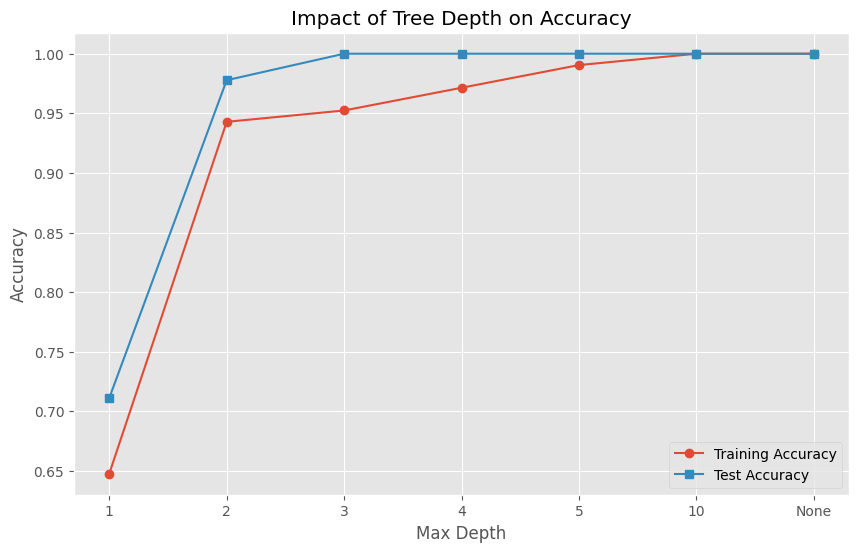

In [21]:
# Examine how max_depth affects model complexity and performance
max_depths = [1, 2, 3, 4, 5, 10, None]  # None means unlimited
train_accuracy = []
test_accuracy = []

for depth in max_depths:
    # Create and train the model
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Calculate accuracy on training and test sets
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    train_accuracy.append(accuracy_score(y_train, y_train_pred))
    test_accuracy.append(accuracy_score(y_test, y_test_pred))
    
    print(f"Max depth: {depth}, Train accuracy: {train_accuracy[-1]:.4f}, Test accuracy: {test_accuracy[-1]:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(len(max_depths)), train_accuracy, marker='o', label='Training Accuracy')
plt.plot(range(len(max_depths)), test_accuracy, marker='s', label='Test Accuracy')
plt.xticks(range(len(max_depths)), [str(d) if d is not None else "None" for d in max_depths])
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Impact of Tree Depth on Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Criterion: gini, Test accuracy: 1.0000
Criterion: entropy, Test accuracy: 0.9778


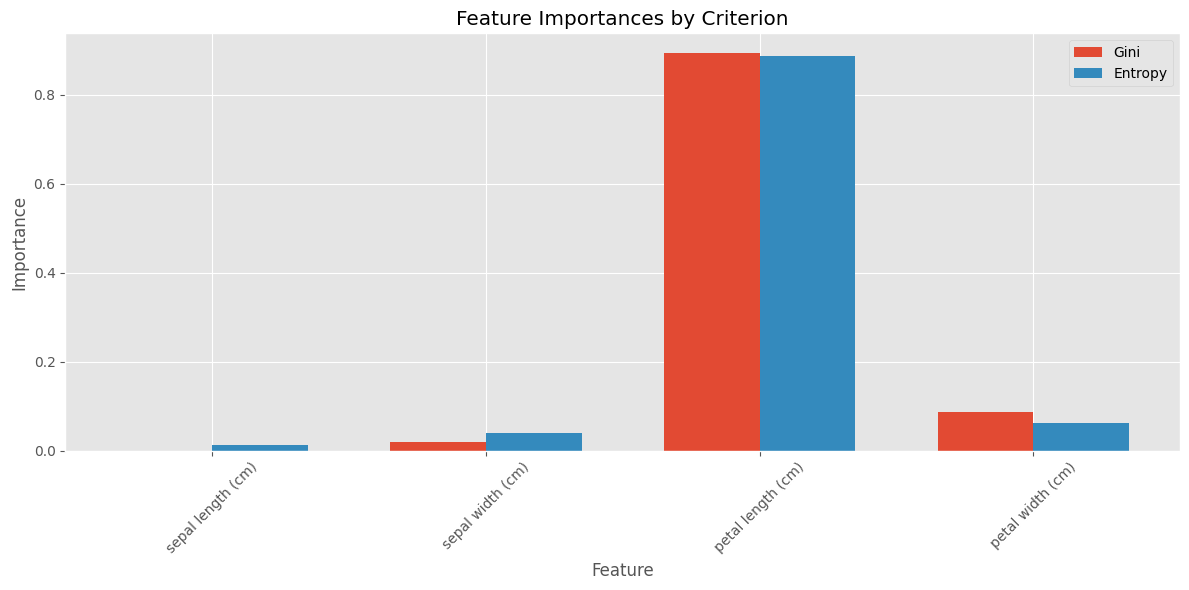

In [22]:
# Compare "gini" vs "entropy" as splitting criteria
criteria = ["gini", "entropy"]
models = {}

for criterion in criteria:
    dt = DecisionTreeClassifier(criterion=criterion, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    models[criterion] = {
        'model': dt,
        'accuracy': accuracy,
        'feature_importances': dt.feature_importances_
    }
    print(f"Criterion: {criterion}, Test accuracy: {accuracy:.4f}")

# Compare feature importances between the two criteria
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = np.arange(len(iris.feature_names))

plt.bar(index, models["gini"]["feature_importances"], bar_width, label="Gini")
plt.bar(index + bar_width, models["entropy"]["feature_importances"], bar_width, label="Entropy")

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances by Criterion")
plt.xticks(index + bar_width / 2, iris.feature_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Best parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation score: 0.9429
Test accuracy with best model: 1.0000


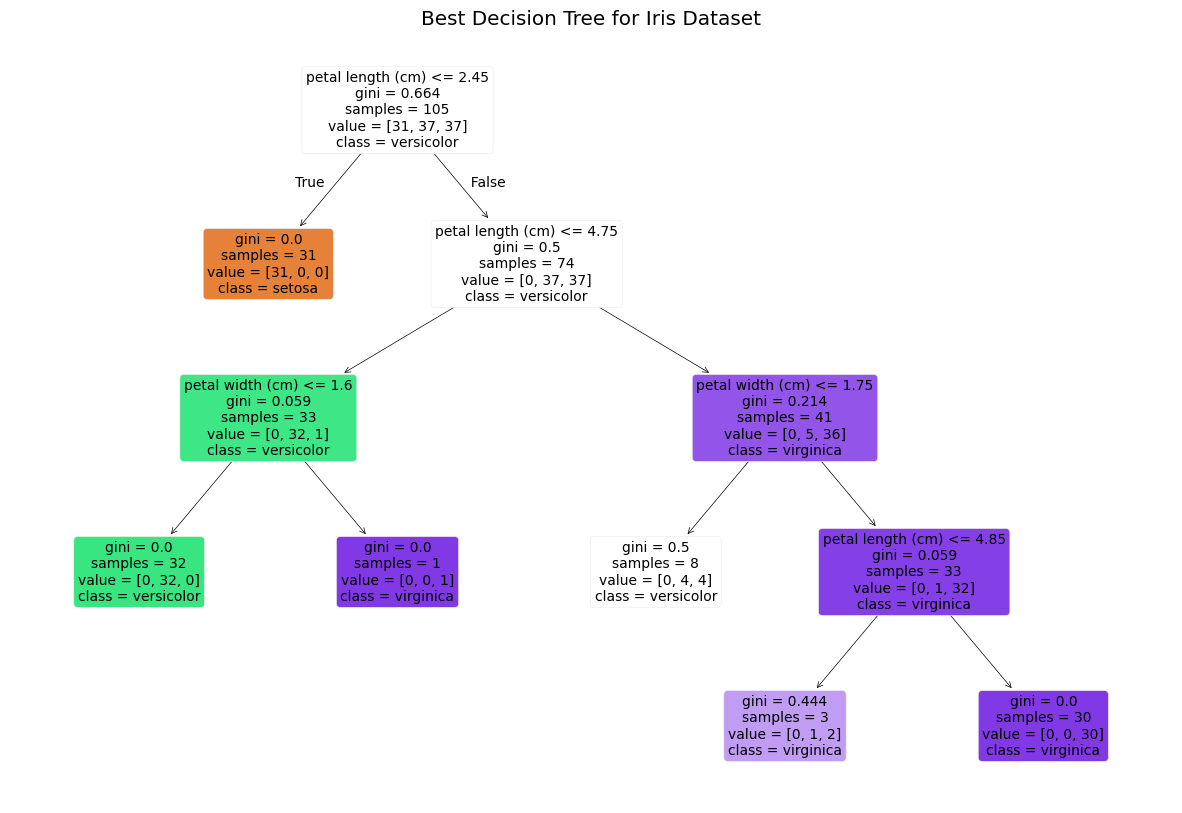

In [23]:
# Find the best combination of hyperparameters using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [3, 4, 5, 6, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Create the grid search
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Print results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate best model on the test set
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
print(f"Test accuracy with best model: {accuracy_score(y_test, y_pred):.4f}")

# Visualize the best tree
plt.figure(figsize=(15, 10))
plot_tree(
    best_dt, 
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Best Decision Tree for Iris Dataset")
plt.show()

## 9. Decision Tree Limitations

While decision trees are powerful and interpretable, they have several limitations that are important to understand.

Feature importances for two trees trained on different samples:
             Feature  Tree 1 Importance  Tree 2 Importance
0  sepal length (cm)           0.016888           0.000000
1   sepal width (cm)           0.000000           0.000000
2  petal length (cm)           0.926489           0.489412
3   petal width (cm)           0.056623           0.510588


<Figure size 1000x600 with 0 Axes>

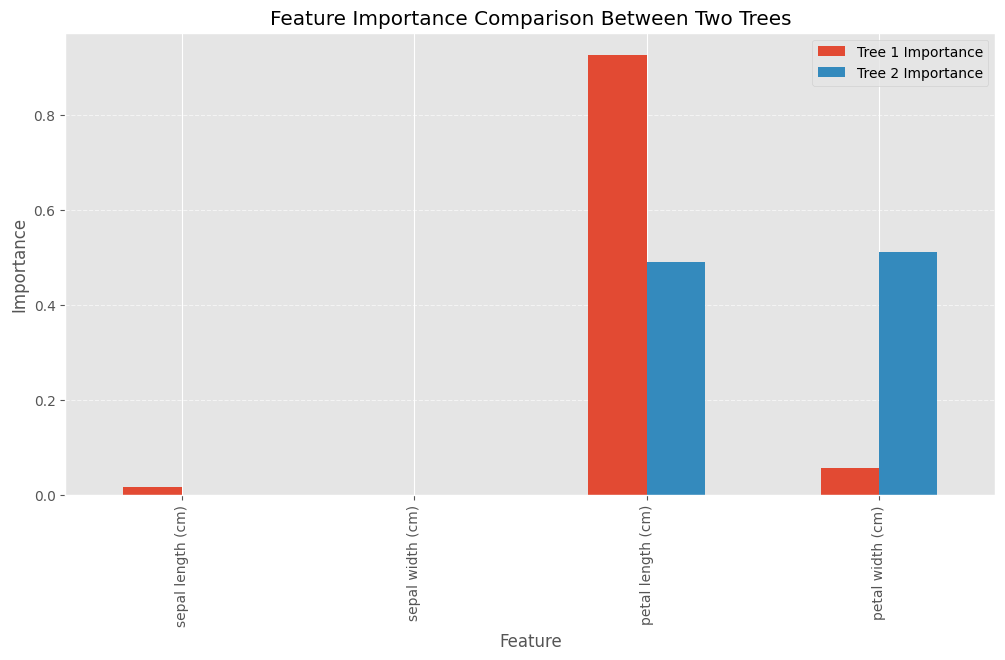

In [24]:
# 1. Sensitivity to small variations in data
# Let's demonstrate how slightly different training sets can lead to different trees

from sklearn.utils import resample

# Create two different bootstrap samples
X_sample1, y_sample1 = resample(X_train, y_train, n_samples=len(X_train)//2, random_state=1)
X_sample2, y_sample2 = resample(X_train, y_train, n_samples=len(X_train)//2, random_state=2)

# Train two trees on different subsets
dt1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt2 = DecisionTreeClassifier(max_depth=3, random_state=42)

dt1.fit(X_sample1, y_sample1)
dt2.fit(X_sample2, y_sample2)

# Compare feature importances
feature_imp_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Tree 1 Importance': dt1.feature_importances_,
    'Tree 2 Importance': dt2.feature_importances_
})

print("Feature importances for two trees trained on different samples:")
print(feature_imp_df)

# Visualize the difference in feature importances
plt.figure(figsize=(10, 6))
feature_imp_df.set_index('Feature').plot(kind='bar')
plt.title('Feature Importance Comparison Between Two Trees')
plt.ylabel('Importance')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [25]:
# 2. Tendency to overfit without proper pruning

# Let's compare a very deep tree (overfitting) vs a properly pruned tree
deep_tree = DecisionTreeClassifier(random_state=42)  # No restrictions
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)  # Controlled depth

deep_tree.fit(X_train, y_train)
pruned_tree.fit(X_train, y_train)

# Evaluate on training and test sets
models = {
    "Deep Tree (Overfitting)": deep_tree,
    "Pruned Tree": pruned_tree
}

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f"{name}:")
    print(f"  - Training accuracy: {train_acc:.4f}")
    print(f"  - Testing accuracy: {test_acc:.4f}")
    print(f"  - Difference (overfitting): {train_acc - test_acc:.4f}")
    print(f"  - Tree depth: {model.get_depth()}")
    print(f"  - Number of leaves: {model.get_n_leaves()}")
    print()

Deep Tree (Overfitting):
  - Training accuracy: 1.0000
  - Testing accuracy: 1.0000
  - Difference (overfitting): 0.0000
  - Tree depth: 6
  - Number of leaves: 10

Pruned Tree:
  - Training accuracy: 0.9524
  - Testing accuracy: 1.0000
  - Difference (overfitting): -0.0476
  - Tree depth: 3
  - Number of leaves: 5



Feature importances:
Meaningful Feature: 1.0000
High Cardinality Feature: 0.0000


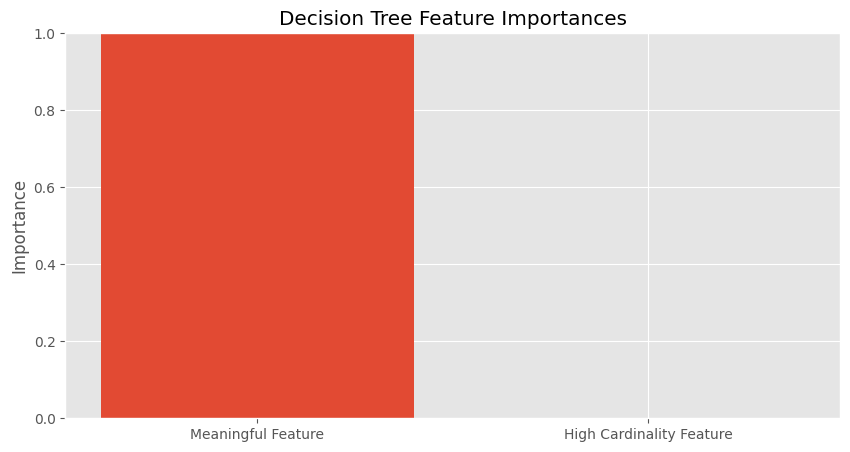

Despite having no real predictive power, the high cardinality feature
can sometimes receive inflated importance due to its many possible splitting points.


In [26]:
# 3. Bias toward features with more levels
# Let's create a synthetic dataset with a categorical feature that has many levels

from sklearn.preprocessing import OrdinalEncoder

# Create a simple dataset with a meaningful feature and a high-cardinality feature
np.random.seed(42)
n_samples = 300

# Create a meaningful numeric feature
X_meaningful = np.random.normal(size=(n_samples, 1))
# Target depends on the meaningful feature
y_synthetic = (X_meaningful > 0).astype(int).flatten()

# Create a categorical feature with many levels but no predictive power
# (essentially random noise)
random_categories = np.random.randint(0, 50, size=n_samples)
X_categorical = random_categories.reshape(-1, 1)

# Combine features
X_synthetic = np.hstack([X_meaningful, X_categorical])

# Encode the categorical feature
encoder = OrdinalEncoder()
X_categorical_encoded = encoder.fit_transform(X_categorical)
X_synthetic_encoded = np.hstack([X_meaningful, X_categorical_encoded])

# Split the data
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_synthetic_encoded, y_synthetic, test_size=0.3, random_state=42)

# Train a decision tree
dt_syn = DecisionTreeClassifier(random_state=42)
dt_syn.fit(X_train_syn, y_train_syn)

# Check feature importances
feature_importances = dt_syn.feature_importances_
feature_names = ['Meaningful Feature', 'High Cardinality Feature']

print("Feature importances:")
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(feature_names, feature_importances)
plt.title('Decision Tree Feature Importances')
plt.ylabel('Importance')
plt.ylim(0, 1)
plt.show()

print("Despite having no real predictive power, the high cardinality feature")
print("can sometimes receive inflated importance due to its many possible splitting points.")

## 10. Practical Applications

Decision trees are used in many real-world applications. Here are some practical examples of how they can be applied.

In [27]:
# Example 1: Feature Importance Analysis
# Let's use a more complex dataset - breast cancer

from sklearn.datasets import load_breast_cancer

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

# Split the data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer, y_cancer, test_size=0.3, random_state=42)

# Train a decision tree with controlled depth to avoid overfitting
cancer_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
cancer_tree.fit(X_train_cancer, y_train_cancer)

# Evaluate
y_pred_cancer = cancer_tree.predict(X_test_cancer)
print(f"Breast cancer prediction accuracy: {accuracy_score(y_test_cancer, y_pred_cancer):.4f}")

# Analyze feature importance
feature_importances = cancer_tree.feature_importances_
feature_names = cancer.feature_names

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Display top 10 features
print("\nTop 10 most important features for breast cancer prediction:")
feature_importance_df.head(10)

Breast cancer prediction accuracy: 0.9532

Top 10 most important features for breast cancer prediction:


,Feature,Importance
7,mean concave points,0.721174
21,worst texture,0.120244
23,worst area,0.068765
20,worst radius,0.040396
29,worst fractal dimension,0.017537
13,area error,0.013857
24,worst smoothness,0.010720
11,texture error,0.007307
3,mean area,0.000000
4,mean smoothness,0.000000


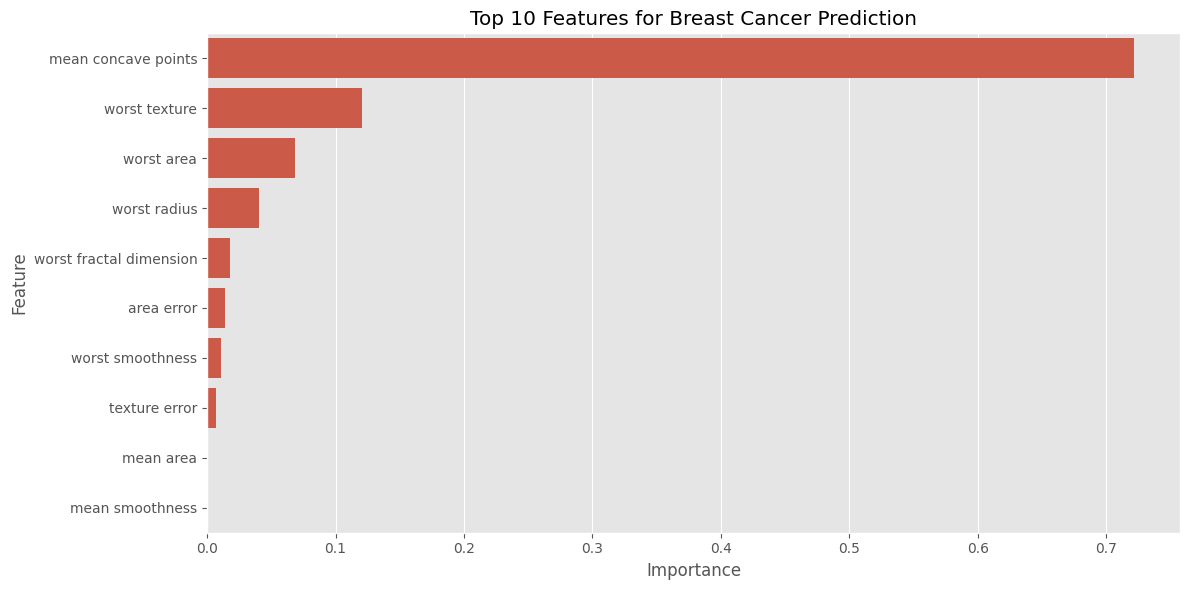

In [28]:
# Visualize top features
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Features for Breast Cancer Prediction')
plt.tight_layout()
plt.show()

In [29]:
# Example 2: Decision Trees as a foundation for Random Forests
# Random Forests are an ensemble of decision trees

from sklearn.ensemble import RandomForestClassifier

# Create and train a Random Forest (ensemble of decision trees)
rf_classifier = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=4,
    random_state=42
)
rf_classifier.fit(X_train, y_train)

# Compare performance with a single decision tree
dt_pred = dt_classifier.predict(X_test)
rf_pred = rf_classifier.predict(X_test)

print("Decision Tree vs Random Forest:")
print(f"Decision Tree accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Random Forest accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# Compare feature importances
feature_importance_comparison = pd.DataFrame({
    'Feature': iris.feature_names,
    'Decision Tree': dt_classifier.feature_importances_,
    'Random Forest': rf_classifier.feature_importances_
})

print("\nFeature Importance Comparison:")
feature_importance_comparison

Decision Tree vs Random Forest:
Decision Tree accuracy: 1.0000
Random Forest accuracy: 1.0000

Feature Importance Comparison:


,Feature,Decision Tree,Random Forest
0,sepal length (cm),0.000000,0.103438
1,sepal width (cm),0.019110,0.034308
2,petal length (cm),0.893264,0.422491
3,petal width (cm),0.087626,0.439763


<Figure size 1000x600 with 0 Axes>

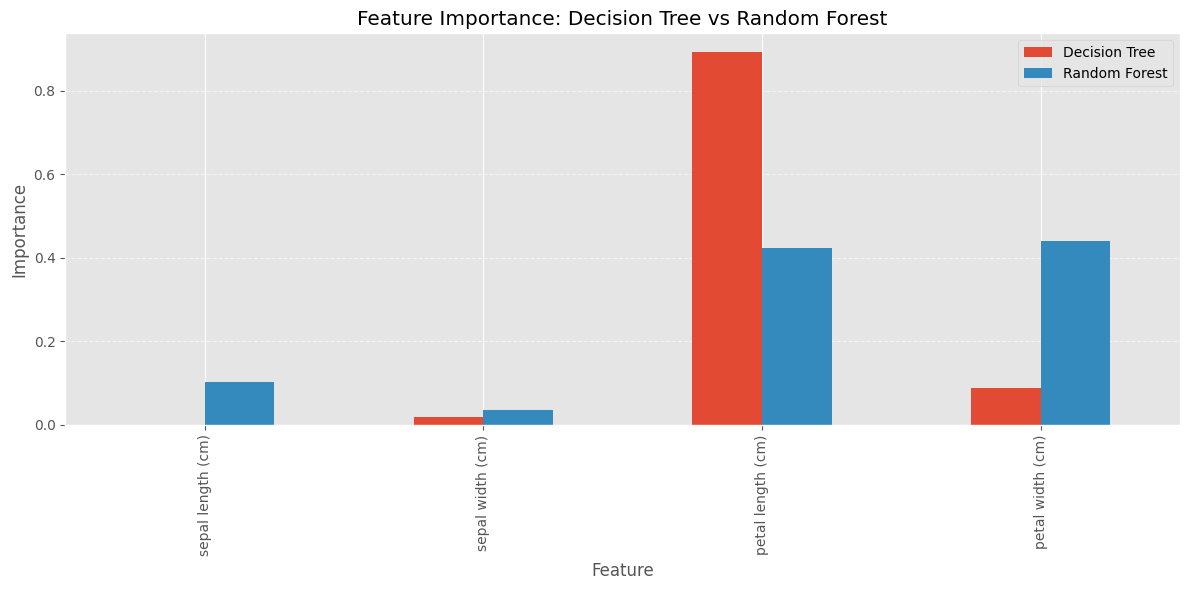

In [30]:
# Visualize feature importance comparison
plt.figure(figsize=(10, 6))
feature_importance_comparison.set_index('Feature').plot(kind='bar')
plt.title('Feature Importance: Decision Tree vs Random Forest')
plt.ylabel('Importance')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Loan approval prediction accuracy: 0.9867

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.95      0.97        63
    Approved       0.99      1.00      0.99       237

    accuracy                           0.99       300
   macro avg       0.99      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300



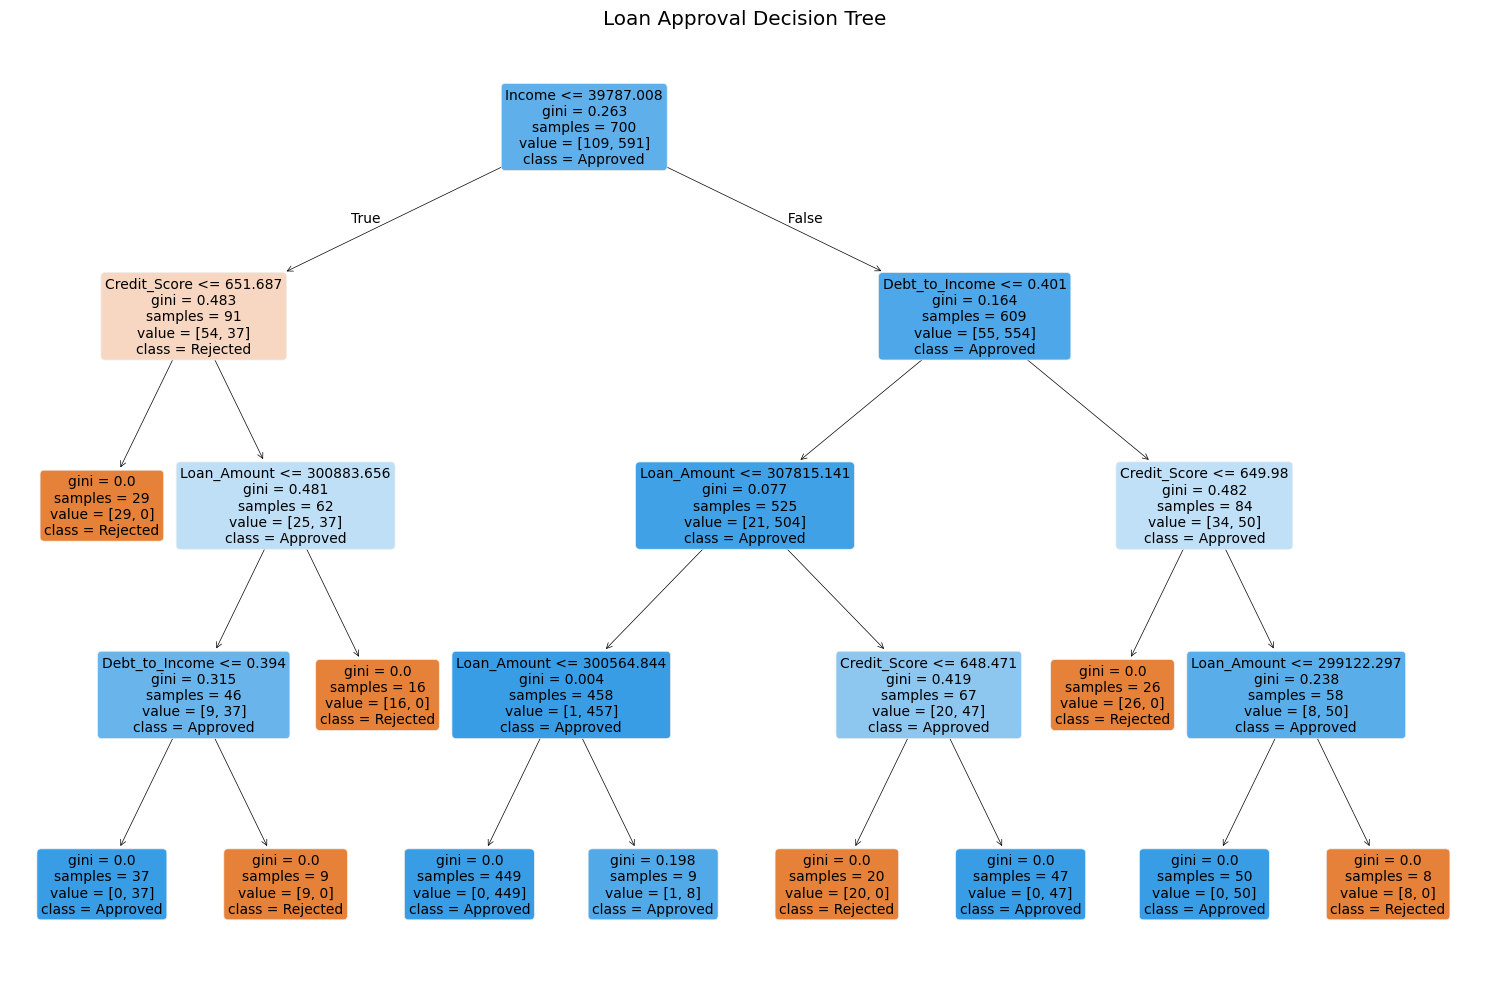

In [31]:
# Example 3: Using decision trees for a real-world classification problem
# Let's create a synthetic dataset representing a loan approval scenario

# Generate synthetic loan approval data
np.random.seed(42)
n_samples = 1000

# Features: age, income, credit_score, loan_amount, debt_to_income_ratio
age = np.random.normal(35, 10, n_samples)
income = np.random.normal(60000, 20000, n_samples)
credit_score = np.random.normal(700, 100, n_samples)
loan_amount = np.random.normal(200000, 100000, n_samples)
debt_to_income = np.random.normal(0.3, 0.1, n_samples)

# Create a synthetic target based on these features
def loan_approval_rule(age, income, credit_score, loan_amount, debt_to_income):
    """Synthetic rule for loan approval"""
    score = (
        0.1 * (age > 25) +
        0.3 * (income > 40000) +
        0.3 * (credit_score > 650) +
        0.2 * (loan_amount < 300000) +
        0.3 * (debt_to_income < 0.4)
    )
    return score > 0.7

# Create target variable
loan_approval = loan_approval_rule(age, income, credit_score, loan_amount, debt_to_income)

# Create feature matrix
X_loan = np.column_stack([age, income, credit_score, loan_amount, debt_to_income])
feature_names_loan = ['Age', 'Income', 'Credit_Score', 'Loan_Amount', 'Debt_to_Income']

# Split data
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(
    X_loan, loan_approval, test_size=0.3, random_state=42
)

# Train a decision tree
loan_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
loan_tree.fit(X_train_loan, y_train_loan)

# Evaluate
y_pred_loan = loan_tree.predict(X_test_loan)
print(f"Loan approval prediction accuracy: {accuracy_score(y_test_loan, y_pred_loan):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_loan, y_pred_loan, target_names=['Rejected', 'Approved']))

# Visualize the decision tree
plt.figure(figsize=(15, 10))
plot_tree(
    loan_tree, 
    feature_names=feature_names_loan,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Loan Approval Decision Tree")
plt.tight_layout()
plt.show()

## Summary

In this notebook, we've explored the fundamental concepts of decision trees in machine learning:

1. **Understanding Decision Trees**: We've learned about nodes, branches, leaves, and splitting criteria.
2. **Building Decision Trees**: We've implemented decision trees using scikit-learn.
3. **Visualizing Trees**: We've seen how to visualize and interpret decision trees.
4. **Making Predictions**: We've traced how predictions are made by following decision paths.
5. **Model Evaluation**: We've evaluated our models using various metrics.
6. **Hyperparameter Tuning**: We've examined how different parameters affect model performance.
7. **Limitations**: We've discussed key limitations of decision trees.
8. **Practical Applications**: We've seen real-world applications of decision trees.

Decision trees are powerful because of their interpretability and ease of use, but they can be prone to overfitting. In practice, they are often used as building blocks for more sophisticated ensemble methods like Random Forests or Gradient Boosting.